## Analysis 2: Phenotype-level Consistency (Kendall's W + Cross-profile Rank Correlation)

The goal is to determine whether gene rankings are driven by the specific phenotypic profile being queried, or whether the same genes tend to rank highly across all profiles regardless of phenotype (which would indicate a systematic scoring bias). (in short, different phenotype should have different rankings in genetic perturbations.)


We use: 
- **Kendall's W**: a coefficient of concordance over the *k* = 16 phenotypes and *n* shared treatment
  - This measures how consistent genes are ranked across all 16 phenotypes
  - W = 0 → profiles rank genes completely independently (rankings are profile-specific, the ideal outcome for distinct phenotypes).  
  - W = 1 → all profiles rank genes in exactly the same order (systematic bias; a gene that ranks #1 for Anaphase also ranks #1 for Interphase, which is biologically implausible).  
  - Values in between indicate partial concordance; moderate W with a structured correlation matrix suggests biological sub-clusters rather than noise.

- **Cross-profile Spearman ρ matrix** — pairwise rank correlation between every pair of profiles.  
  - This measures whether two profiles rank genes differently, as expected if buscar is capturing distinct phenotypic signals
  - Positive ρ (blue) → the two profiles tend to promote the same genes, suggesting shared biology or other features that are in common.  
  - Negative ρ (red) → genes that are top hits for one profile rank poorly for the other — strong evidence of profile-specific signal.  
  - Near-zero ρ (white) → rankings are essentially independent between those two profiles.

A well-behaved analysis should show negative or near-zero off-diagonal correlations between biologically distinct profiles (e.g., Interphase vs. Prometaphase), and modest positive correlations only between phenotypically similar profiles (e.g., Metaphase and Prometaphase, or Anaphase and Apoptosis).

In [69]:
suppressPackageStartupMessages({
    library(arrow)
    library(dplyr)
    library(tidyr)
    library(ggplot2)
    library(pheatmap)
    library(grid)
})

options(warn = -1)

In [70]:
# Input data directory
results_dir <- normalizePath('../results/moa_analysis', mustWork = TRUE)

# Output directory for this notebook's figures/tables
gene_rel_dir <- normalizePath(file.path(getwd(), 'all-plots', 'gene-ranking-relationships'), mustWork = FALSE)
dir.create(gene_rel_dir, recursive = TRUE, showWarnings = FALSE)

In [71]:
# Load real and shuffled BuSCaR outputs
moa_results_df <- read_parquet(file.path(results_dir, 'original_mitocheck_moa_analysis_results.parquet')) %>% as_tibble()
shuffled_moa_results_df <- read_parquet(file.path(results_dir, 'shuffled_mitocheck_moa_analysis_results.parquet')) %>% as_tibble()

# Compute on_rank and off_rank independently per ref_profile.
# Lower score = better rank (rank 1). NaNs/NAs are ranked last.
rerank_by_profile <- function(input_df) {
  input_df %>%
    group_by(ref_profile) %>%
    mutate(
      on_rank = {
        ord <- order(is.na(on_score), on_score, treatment)
        rank_vals <- integer(n())
        rank_vals[ord] <- seq_len(n())
        rank_vals
      },
      off_rank = {
        ord <- order(is.na(off_score), off_score, treatment)
        rank_vals <- integer(n())
        rank_vals[ord] <- seq_len(n())
        rank_vals
      }
    ) %>%
    ungroup()
}

moa_results_df <- rerank_by_profile(moa_results_df)
shuffled_moa_results_df <- rerank_by_profile(shuffled_moa_results_df)

head(moa_results_df)

rank,ref_profile,treatment,on_score,off_score,proportion,on_rank,off_rank
<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<int>
1,Polylobed,KIF20A,4.736952e-15,0,0.50000000,13,28
1,Polylobed,TOP1,2.273737e-14,0,0.06944444,28,39
1,Polylobed,ENSG00000173227,0.000000e+00,0,0.40000000,6,19
NA,Polylobed,ENSG00000116641,NA,NA,NA,59,59
1,Polylobed,ch-TOG,0.000000e+00,0,0.01351351,3,9
1,Polylobed,ENSG00000148826,4.440892e-15,0,0.24242424,11,17


In [72]:
# Keep rows where both on_score and off_score are present
prepare_df <- function(results_df) {
  results_df %>%
    as.data.frame() %>%
    filter(!is.na(on_score), !is.na(off_score))
}

df <- prepare_df(moa_results_df)
shuf_df <- prepare_df(shuffled_moa_results_df)

In [73]:
build_rank_bundle <- function(input_df, rank_col = 'on_rank') {
  rank_pivot <- input_df %>%
    select(ref_profile, treatment, all_of(rank_col)) %>%
    pivot_wider(names_from = ref_profile, values_from = all_of(rank_col))

  rank_pivot_complete <- rank_pivot %>% drop_na()

  rank_pivot_reranked <- rank_pivot_complete %>%
    select(-treatment) %>%
    mutate(across(everything(), ~ rank(.x, ties.method = 'average')))

  # Use sparse, profile-wise rank matrix for pairwise correlations.
  # This avoids collapsing to ~1 treatment for shuffled data after complete-case filtering.
  rank_matrix_sparse <- rank_pivot %>%
    select(-treatment) %>%
    mutate(across(everything(), ~ rank(.x, ties.method = 'average', na.last = 'keep')))

  list(
    rank_pivot = rank_pivot,
    rank_pivot_complete = rank_pivot_complete,
    rank_pivot_reranked = rank_pivot_reranked,
    rank_matrix_sparse = rank_matrix_sparse,
    n_subjects = nrow(rank_pivot_reranked),
    k_raters = ncol(rank_pivot_reranked),
    profile_names = colnames(rank_matrix_sparse)
  )
}

orig_on_bundle  <- build_rank_bundle(df,      rank_col = 'on_rank')
orig_off_bundle <- build_rank_bundle(df,      rank_col = 'off_rank')
shuf_on_bundle  <- build_rank_bundle(shuf_df, rank_col = 'on_rank')
shuf_off_bundle <- build_rank_bundle(shuf_df, rank_col = 'off_rank')

This analysis first measures global agreement in gene rankings across all phenotypes using Kendall's W. It then computes pairwise Spearman correlations between phenotype-specific gene rankings and visualizes them as a heatmap. Together, these metrics show whether ranking patterns are phenotype-specific or reflect a shared global trend.

In [74]:
# options for rendering the figure larger
height <- 12
width <- 14
options(repr.plot.width = width, repr.plot.height = height)

compute_consistency <- function(bundle) {
  R_complete <- as.matrix(bundle$rank_pivot_reranked)

  if (nrow(R_complete) > 1 && ncol(R_complete) > 1) {
    rank_sums <- rowSums(R_complete)
    S <- sum((rank_sums - mean(rank_sums))^2)
    W <- (12 * S) / (bundle$k_raters^2 * (bundle$n_subjects^3 - bundle$n_subjects))
    chi2_stat <- bundle$k_raters * (bundle$n_subjects - 1) * W
    chi2_pval <- pchisq(chi2_stat, df = bundle$n_subjects - 1, lower.tail = FALSE)
    w_label <- sprintf('%.3f', W)
  } else {
    W <- NA_real_
    chi2_stat <- NA_real_
    chi2_pval <- NA_real_
    w_label <- 'NA (insufficient complete-case treatments)'
  }

  # Pairwise correlation on sparse rank matrix preserves shuffled information.
  # This avoids collapsing to ~1 treatment for shuffled data after complete-case filtering.
  R_sparse <- as.matrix(bundle$rank_matrix_sparse)
  corr_matrix <- cor(R_sparse, method = 'spearman', use = 'pairwise.complete.obs')

  diag(corr_matrix) <- 1
  corr_long <- as.data.frame(as.table(corr_matrix))
  colnames(corr_long) <- c('y', 'x', 'rho')
  corr_long$x <- factor(corr_long$x, levels = bundle$profile_names)
  corr_long$y <- factor(corr_long$y, levels = rev(bundle$profile_names))

  list(
    W = W,
    w_label = w_label,
    chi2_stat = chi2_stat,
    chi2_pval = chi2_pval,
    corr_matrix = corr_matrix,
    corr_long = corr_long,
    n_subjects = bundle$n_subjects,
    k_raters = bundle$k_raters
  )
}

plot_corr_heatmap <- function(consistency, title_suffix = '') {
  ggplot(consistency$corr_long, aes(x = x, y = y, fill = rho)) +
    geom_tile(color = 'white', linewidth = 0.3) +
    geom_text(aes(label = ifelse(is.na(rho), 'NA', sprintf('%.2f', rho))), size = 6.3, color = '#222222') +
    scale_fill_gradient2(
      low = '#d62728',
      mid = '#f7f7f7',
      high = '#1f77b4',
      midpoint = 0,
      limits = c(-1, 1),
      na.value = 'grey80'
    ) +
    labs(
      title = sprintf(
        "Cross-phenotype Spearman rank correlation ρ %s\nKendall's W = %s  (complete-case n = %d, %d phenotypic states)",
        title_suffix, consistency$w_label, consistency$n_subjects, consistency$k_raters
      ),
      x = NULL,
      y = NULL,
      fill = 'Spearman rank correlation'
    ) +
    theme_minimal(base_size = 20) +
    theme(
      plot.title = element_text(face = 'bold', size = 25, hjust = 0.5, color = '#1a1a2e'),
      axis.text.x = element_text(angle = 45, hjust = 1, size = 20, color = '#222222'),
      axis.text.y = element_text(size = 20, color = '#222222'),
      legend.title = element_text(face = 'bold', size = 22, color = '#1a1a2e'),
      legend.text = element_text(size = 20, color = '#222222'),
      panel.grid = element_blank()
    )
}

save_and_print_corr <- function(consistency, file_name, title_suffix = '', label = 'original') {
  cat(sprintf("[%s] Kendall's W = %s\n", label, consistency$w_label))
  cat(sprintf('[%s] complete-case n = %d, k = %d\n', label, consistency$n_subjects, consistency$k_raters))

  if (!is.na(consistency$chi2_stat)) {
    cat(sprintf('[%s] χ²(%d) = %.4f,  p = %.4e\n', label, consistency$n_subjects - 1, consistency$chi2_stat, consistency$chi2_pval))
  }

  p_corr <- plot_corr_heatmap(consistency, title_suffix)
  out_path <- file.path(gene_rel_dir, file_name)
  ggsave(out_path, p_corr, width = width, height = height, dpi = 300, bg = 'white')
  cat(sprintf('[%s] Saved -> %s\n', label, out_path))
  print(p_corr)
}

orig_on_consistency  <- compute_consistency(orig_on_bundle)
orig_off_consistency <- compute_consistency(orig_off_bundle)
shuf_on_consistency  <- compute_consistency(shuf_on_bundle)
shuf_off_consistency <- compute_consistency(shuf_off_bundle)

[original on_rank] Saved -> /home/erikserrano/Projects/buscar/notebooks/3.mitocheck-analysis/plots/all-plots/gene-ranking-relationships/original_on_rank_clustermap.png


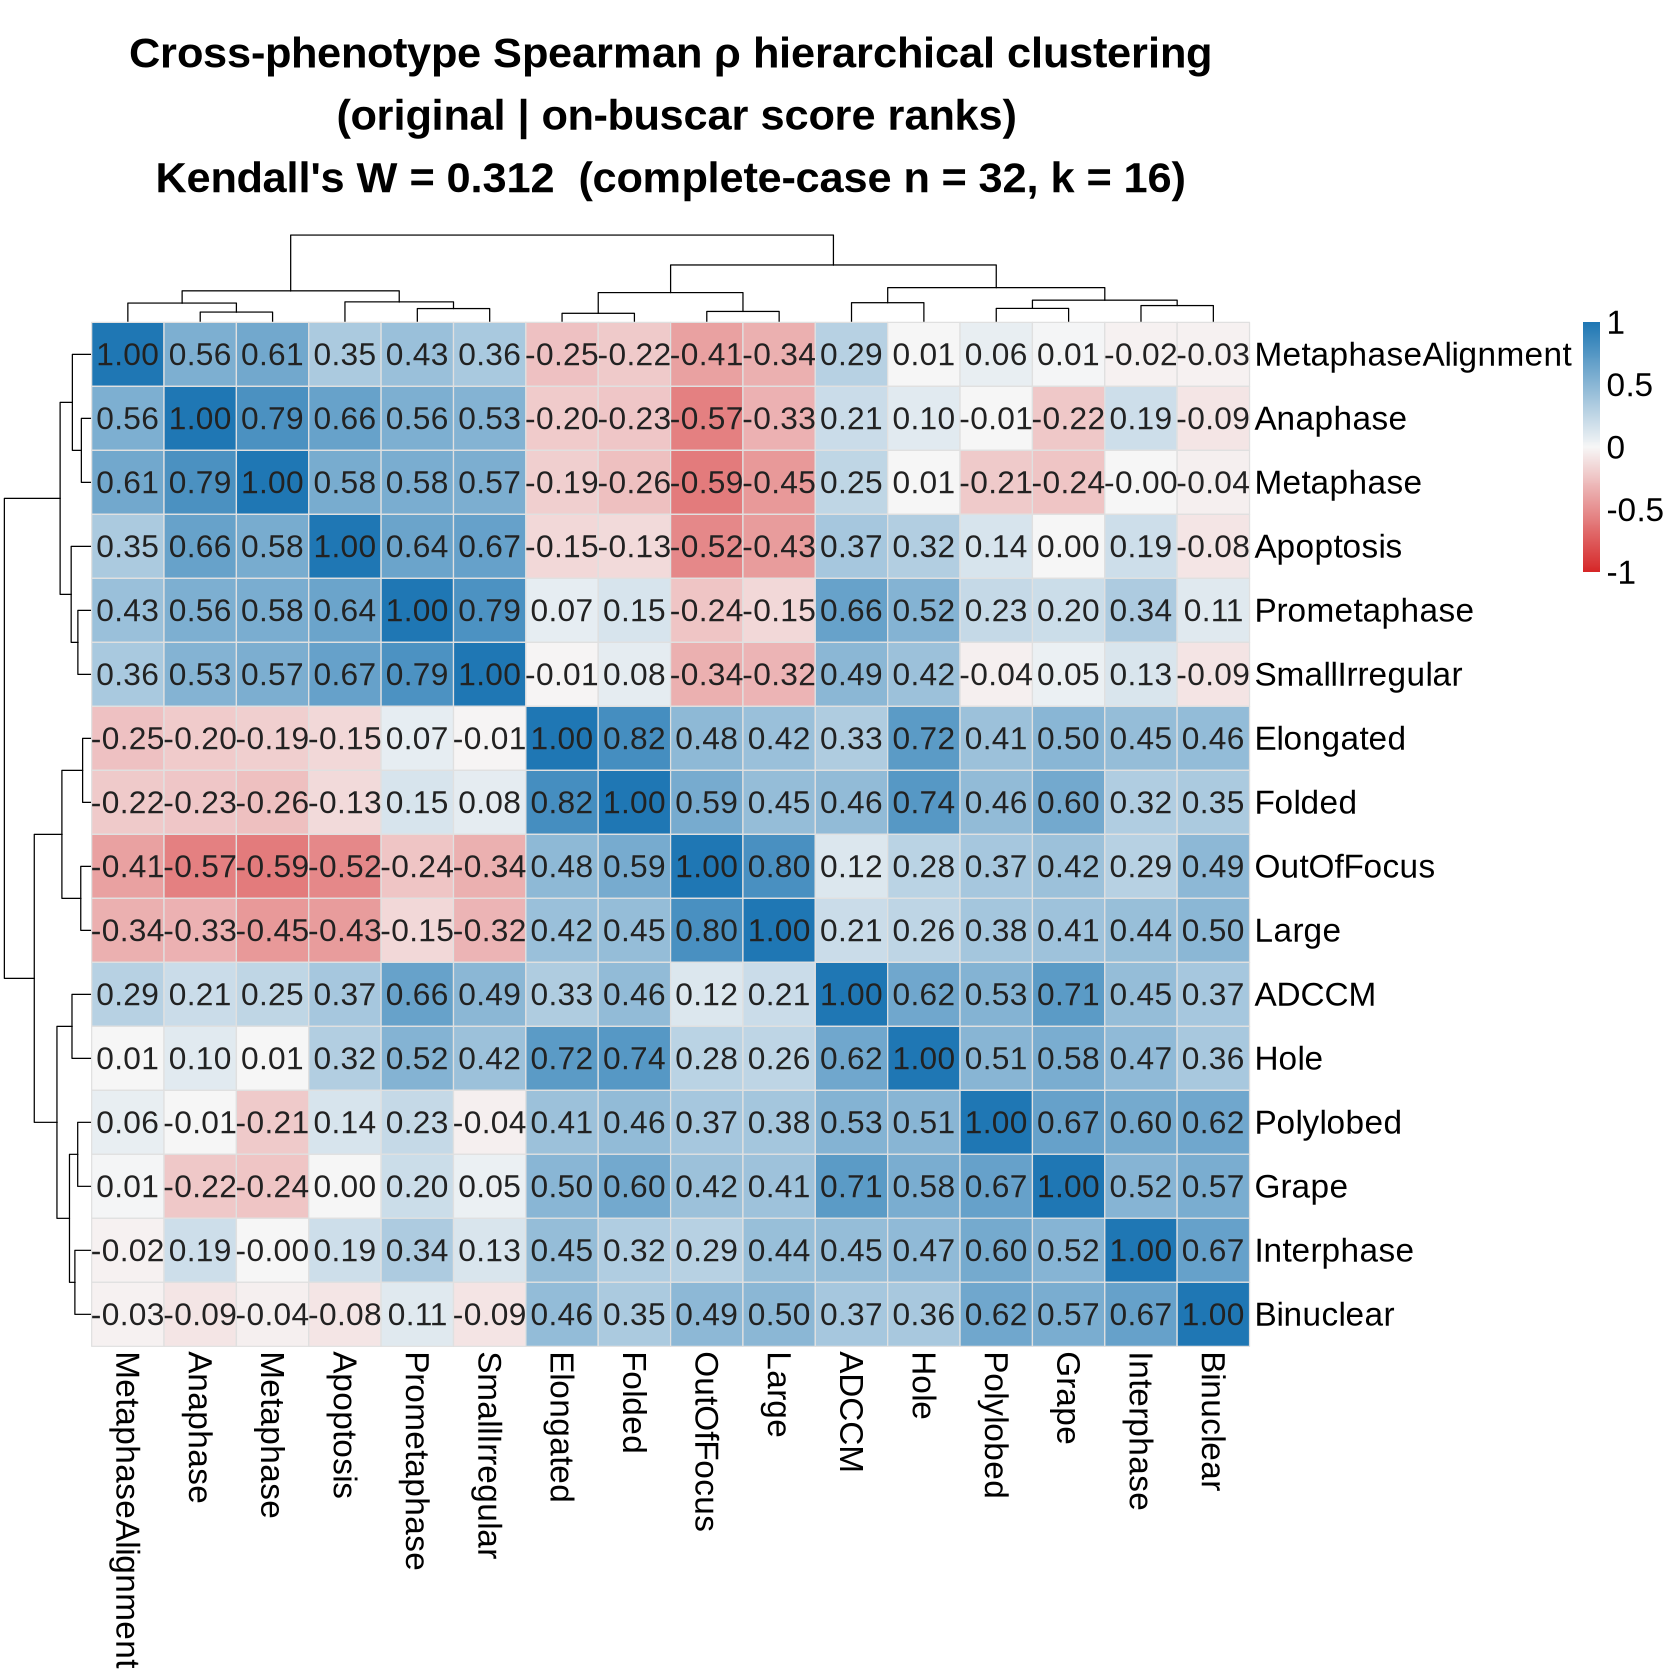

[original off_rank] Saved -> /home/erikserrano/Projects/buscar/notebooks/3.mitocheck-analysis/plots/all-plots/gene-ranking-relationships/original_off_rank_clustermap.png


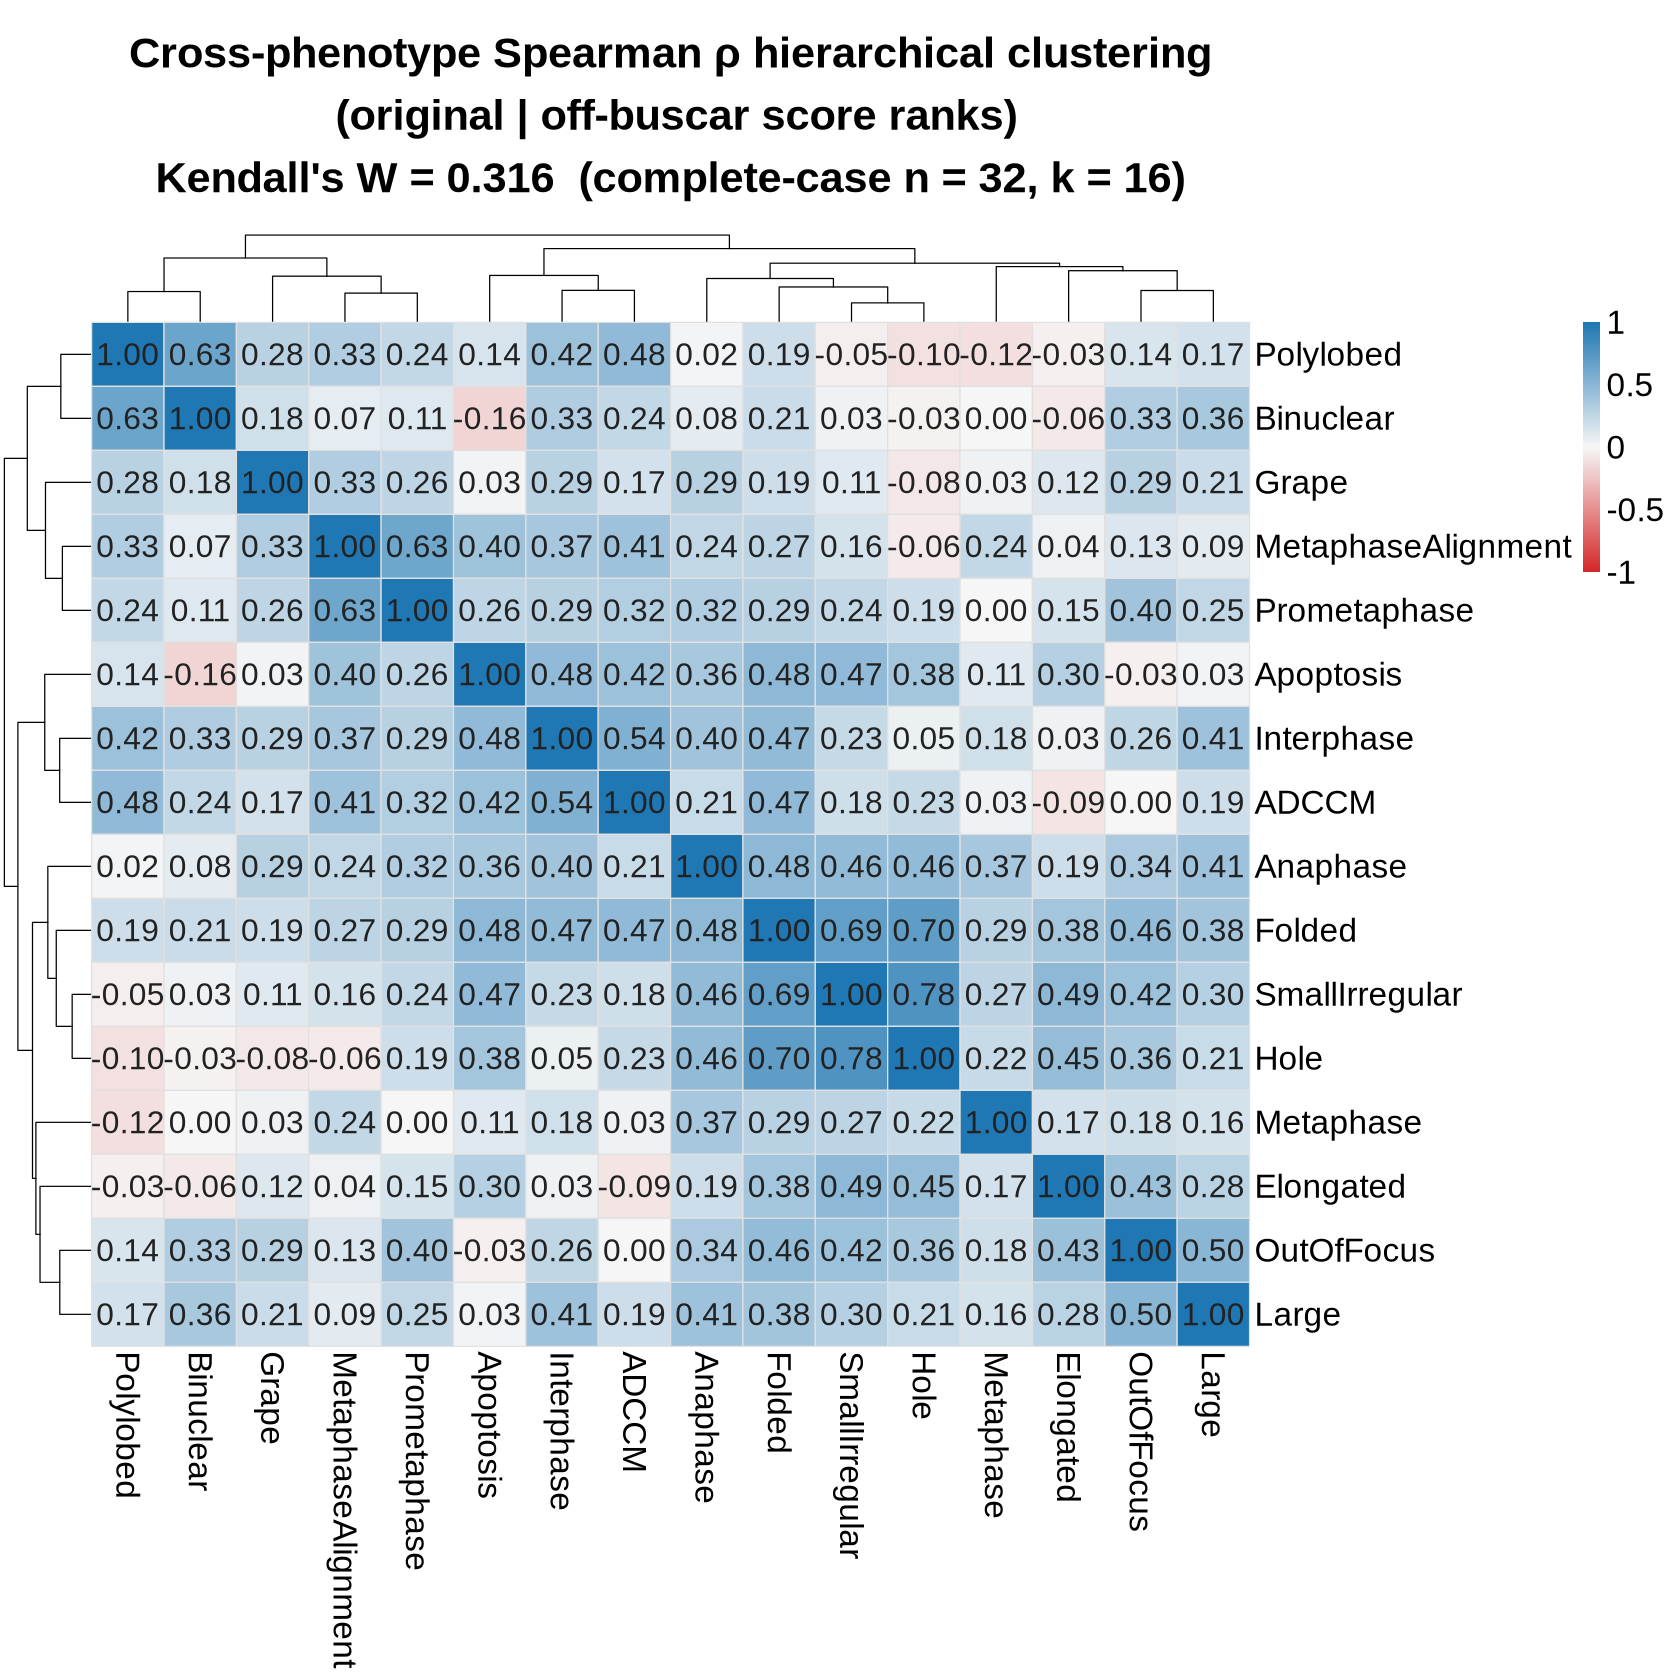

[shuffled on_rank] Saved -> /home/erikserrano/Projects/buscar/notebooks/3.mitocheck-analysis/plots/all-plots/gene-ranking-relationships/shuffled_on_rank_clustermap.png


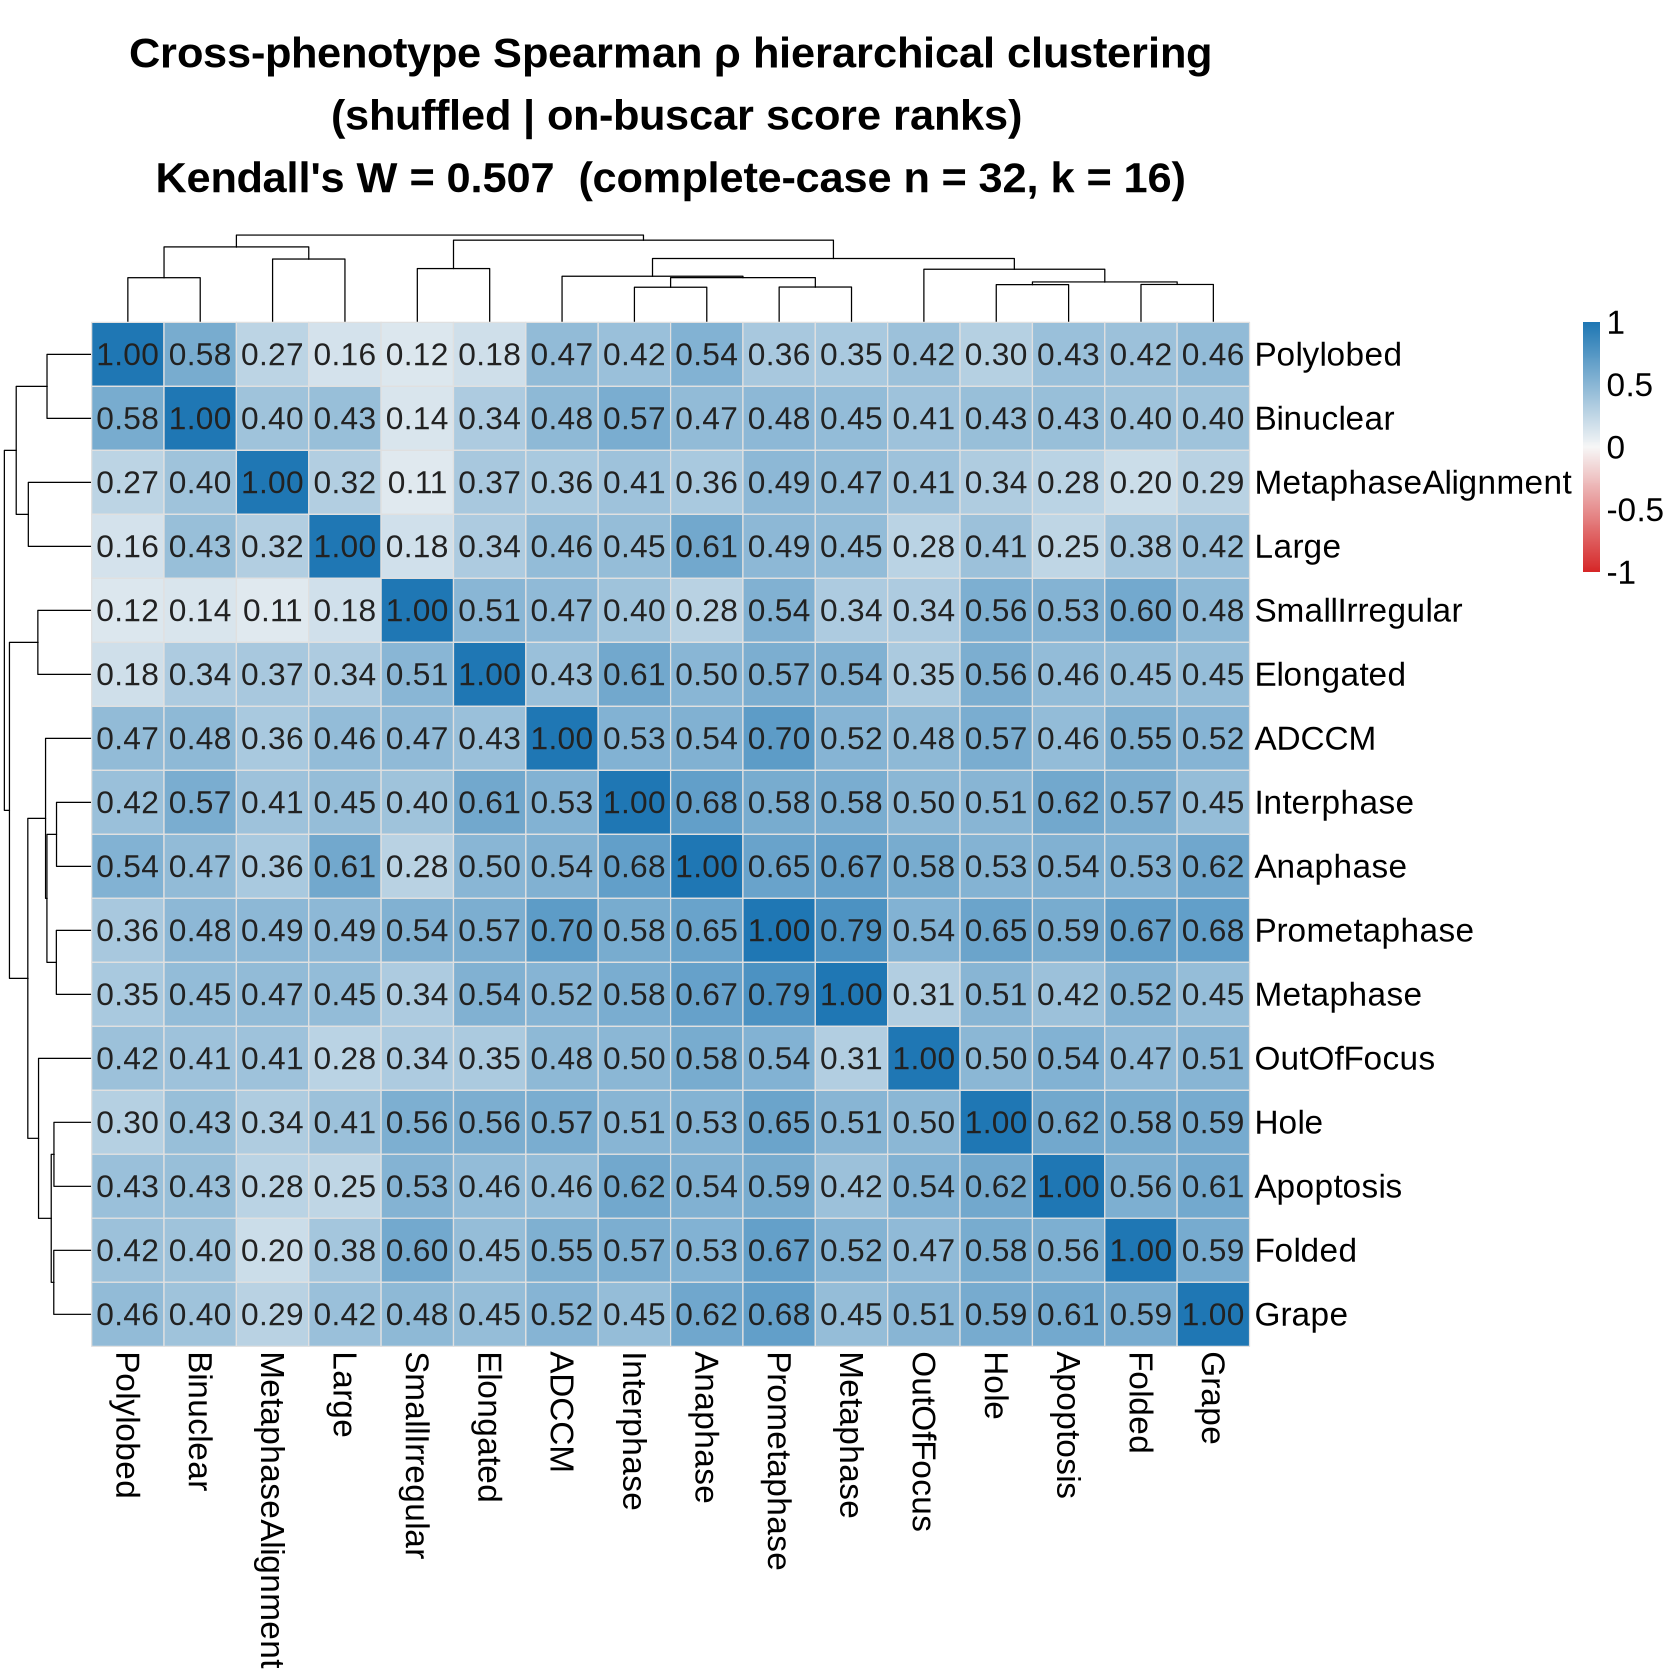

[shuffled off_rank] Saved -> /home/erikserrano/Projects/buscar/notebooks/3.mitocheck-analysis/plots/all-plots/gene-ranking-relationships/shuffled_off_rank_clustermap.png


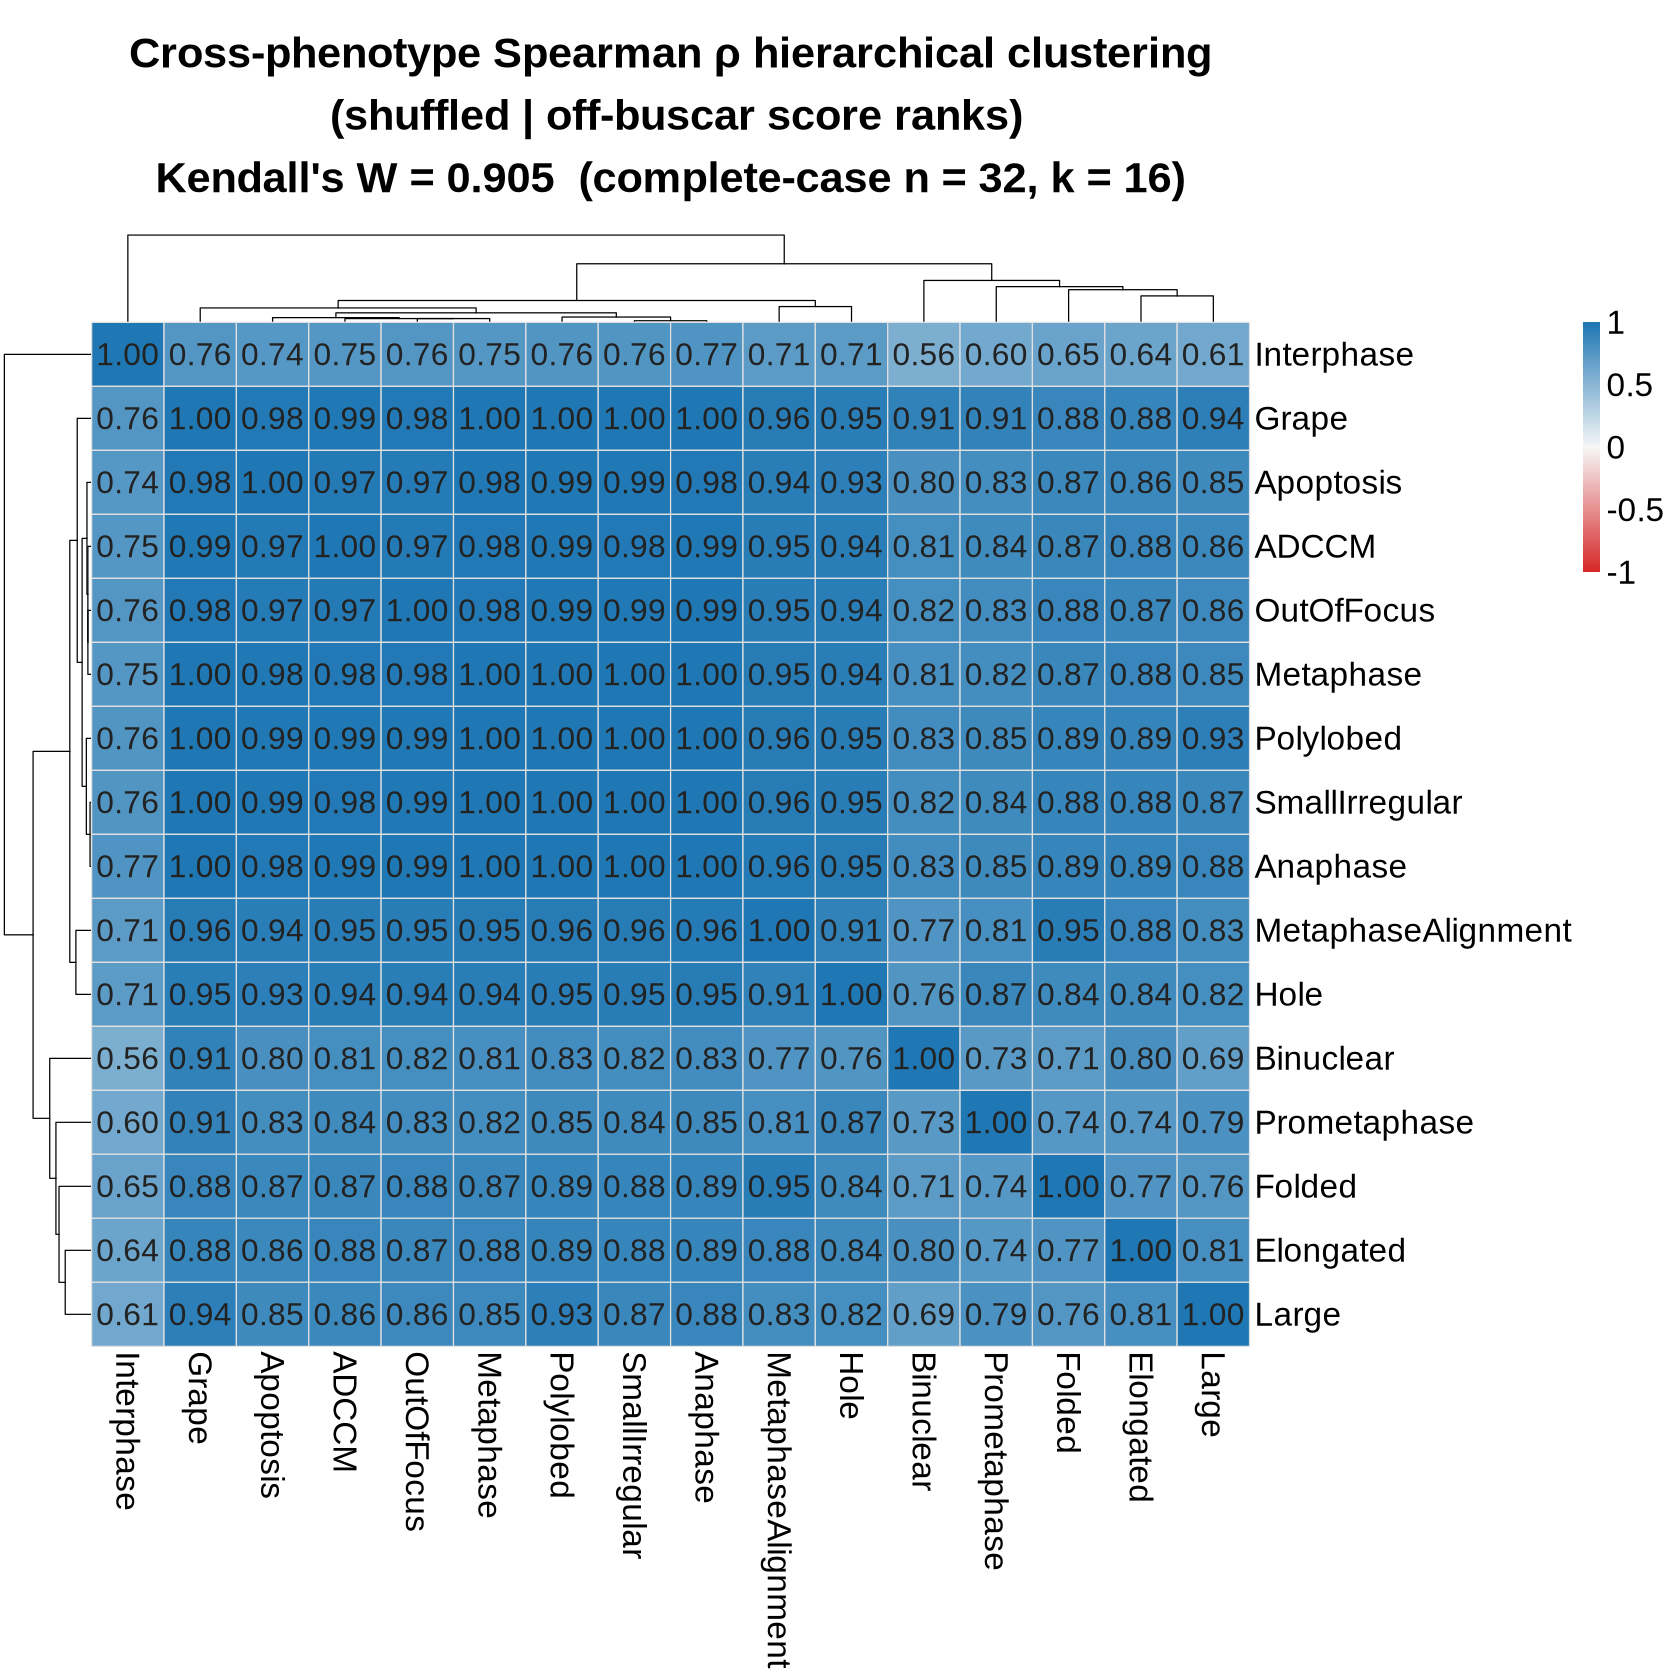

In [75]:
# options for rendering the figure larger
height <- 14
width <- 14
options(repr.plot.width = width, repr.plot.height = height)

save_corr_clustermap <- function(consistency, file_name, title_suffix = '', label = 'original') {
  corr_clean <- consistency$corr_matrix
  corr_clean[is.na(corr_clean)] <- 0

  anno_numbers <- ifelse(is.na(consistency$corr_matrix), 'NA', sprintf('%.2f', consistency$corr_matrix))
  dim(anno_numbers) <- dim(consistency$corr_matrix)

  pheat <- pheatmap(
    corr_clean,
    color = colorRampPalette(c('#d62728', '#f7f7f7', '#1f77b4'))(256),
    breaks = seq(-1, 1, length.out = 257),
    cluster_rows = TRUE,
    cluster_cols = TRUE,
    display_numbers = anno_numbers,
    number_color = '#222222',
    fontsize = 20,
    fontsize_row = 20,
    fontsize_col = 20,
    fontsize_number = 19,
    border_color = '#e0e0e0',
    main = sprintf(
      "Cross-phenotype Spearman ρ hierarchical clustering\n%s\nKendall's W = %s  (complete-case n = %d, k = %d)",
      title_suffix, consistency$w_label, consistency$n_subjects, consistency$k_raters
    )
  )

  out_path <- file.path(gene_rel_dir, file_name)
  png(out_path, width = 14, height = 14, units = 'in', res = 300)
  grid::grid.newpage()
  grid::grid.draw(pheat$gtable)
  dev.off()
  cat(sprintf('[%s] Saved -> %s\n', label, out_path))
  grid::grid.newpage()
  grid::grid.draw(pheat$gtable)
}

# Original data — on_rank
save_corr_clustermap(orig_on_consistency,  'original_on_rank_clustermap.png',  ' (original | on-buscar score ranks)',  'original on_rank')

# Original data — off_rank
save_corr_clustermap(orig_off_consistency, 'original_off_rank_clustermap.png', ' (original | off-buscar score ranks)', 'original off_rank')

# Shuffled data — on_rank
save_corr_clustermap(shuf_on_consistency,  'shuffled_on_rank_clustermap.png',  ' (shuffled | on-buscar score ranks)',  'shuffled on_rank')

# Shuffled data — off_rank
save_corr_clustermap(shuf_off_consistency, 'shuffled_off_rank_clustermap.png', ' (shuffled | off-buscar score ranks)', 'shuffled off_rank')

The real data (W = 0.348) produced biologically coherent clusters  mitotic phenotypes (Prometaphase, Anaphase, Metaphase) grouped together with high positive correlations, while morphologically distinct states like Large and OutOfFocus showed negative correlations against the mitotic cluster. The shuffled data (W = 0.528) lost this entirely, collapsing into uniformly moderate positive correlations with no meaningful clustering structure and no negative correlations.

## Real vs Permutation Null

This section tests whether the observed concordance in gene rankings (Kendall's W) is driven by genuine biological signal or is simply a structural artifact of the data.

- **Real W**: concordance computed from the original gene rankings across all phenotypic states.
- **Permutation-null W**: concordance after randomly shuffling which gene receives which row of rankings (label permutation). This preserves each gene's rank profile but breaks the alignment between genes and profiles, destroying any real signal while keeping data structure intact.

**Interpretation:** if real W is much larger than the permutation null distribution, the observed agreement across phenotypes is unlikely to have arisen by chance.


In [76]:
# Compute Kendall's W (and chi-square p-value) from a complete-case rank matrix
compute_kendall_w_from_matrix <- function(rank_matrix_complete) {
  n_subjects <- nrow(rank_matrix_complete)
  k_raters <- ncol(rank_matrix_complete)

  if (n_subjects <= 1 || k_raters <= 1) {
    return(list(
      W = NA_real_,
      p_value = NA_real_,
      chi2_stat = NA_real_,
      n_subjects = n_subjects,
      k_raters = k_raters
    ))
  }

  row_rank_sums <- rowSums(rank_matrix_complete)
  S <- sum((row_rank_sums - mean(row_rank_sums))^2)
  W <- (12 * S) / (k_raters^2 * (n_subjects^3 - n_subjects))

  chi2_stat <- k_raters * (n_subjects - 1) * W
  p_value <- pchisq(chi2_stat, df = n_subjects - 1, lower.tail = FALSE)

  list(
    W = W,
    p_value = p_value,
    chi2_stat = chi2_stat,
    n_subjects = n_subjects,
    k_raters = k_raters
  )
}

In [77]:
# Build complete-case rank matrices from original and shuffled data and compute observed W
R_real <- as.matrix(orig_bundle$rank_pivot_reranked)
R_shuf <- as.matrix(shuf_bundle$rank_pivot_reranked)

real_stats <- compute_kendall_w_from_matrix(R_real)
shuf_stats <- compute_kendall_w_from_matrix(R_shuf)

cat(sprintf('Observed W (original) = %.3f\n', real_stats$W))
cat(sprintf('Observed W (shuffled) = %.3f\n', shuf_stats$W))


Observed W (original) = 0.312
Observed W (shuffled) = 0.507
Observed W (shuffled) = 0.507


In [78]:
# Permutation settings
set.seed(0)
n_permutations <- 5000

# Null model: for each phenotype column, independently shuffle which gene receives
# which rank. This keeps the within-phenotype rank distribution intact but destroys
# the cross-phenotype concordance signal -- the standard null for Kendall's W.
perm_W <- replicate(n_permutations, {
  R_perm <- apply(R_real, 2, sample, replace = FALSE)
  if (is.vector(R_perm)) R_perm <- matrix(R_perm, ncol = ncol(R_real))
  compute_kendall_w_from_matrix(R_perm)$W
})

perm_W <- perm_W[!is.na(perm_W)]
empirical_p_real <- if (length(perm_W) > 0) mean(perm_W >= real_stats$W) else NA_real_
z_vs_perm <- if (length(perm_W) > 1 && sd(perm_W) > 0) (real_stats$W - mean(perm_W)) / sd(perm_W) else NA_real_

summary_tbl <- tibble::tibble(
  comparison = c('real', 'perm_null_mean', 'perm_null_sd', 'empirical_p_real_vs_perm', 'zscore_real_vs_perm'),
  value = c(
    real_stats$W,
    ifelse(length(perm_W) > 0, mean(perm_W), NA_real_),
    ifelse(length(perm_W) > 1, sd(perm_W), NA_real_),
    empirical_p_real,
    z_vs_perm
  )
)

print(summary_tbl)

summary_out <- file.path(gene_rel_dir, 'kendall_w_real_permutation_summary.csv')
readr::write_csv(summary_tbl, summary_out)
cat(sprintf('Saved -> %s\n', summary_out))


# A tibble: 5 × 2
  comparison                 value
  <chr>                      <dbl>
1 real                      0.312 
2 perm_null_mean            0.0625
3 perm_null_sd              0.0155
4 empirical_p_real_vs_perm  0     
5 zscore_real_vs_perm      16.1   
Saved -> /home/erikserrano/Projects/buscar/notebooks/3.mitocheck-analysis/plots/all-plots/gene-ranking-relationships/kendall_w_real_permutation_summary.csv
Saved -> /home/erikserrano/Projects/buscar/notebooks/3.mitocheck-analysis/plots/all-plots/gene-ranking-relationships/kendall_w_real_permutation_summary.csv


Saved -> /home/erikserrano/Projects/buscar/notebooks/3.mitocheck-analysis/plots/all-plots/gene-ranking-relationships/kendall_w_permutation_null_histogram.png
Saved -> /home/erikserrano/Projects/buscar/notebooks/3.mitocheck-analysis/plots/all-plots/gene-ranking-relationships/profile_specificity_real_vs_shuffled.csv
Saved -> /home/erikserrano/Projects/buscar/notebooks/3.mitocheck-analysis/plots/all-plots/gene-ranking-relationships/profile_specificity_real_vs_shuffled_wide.csv


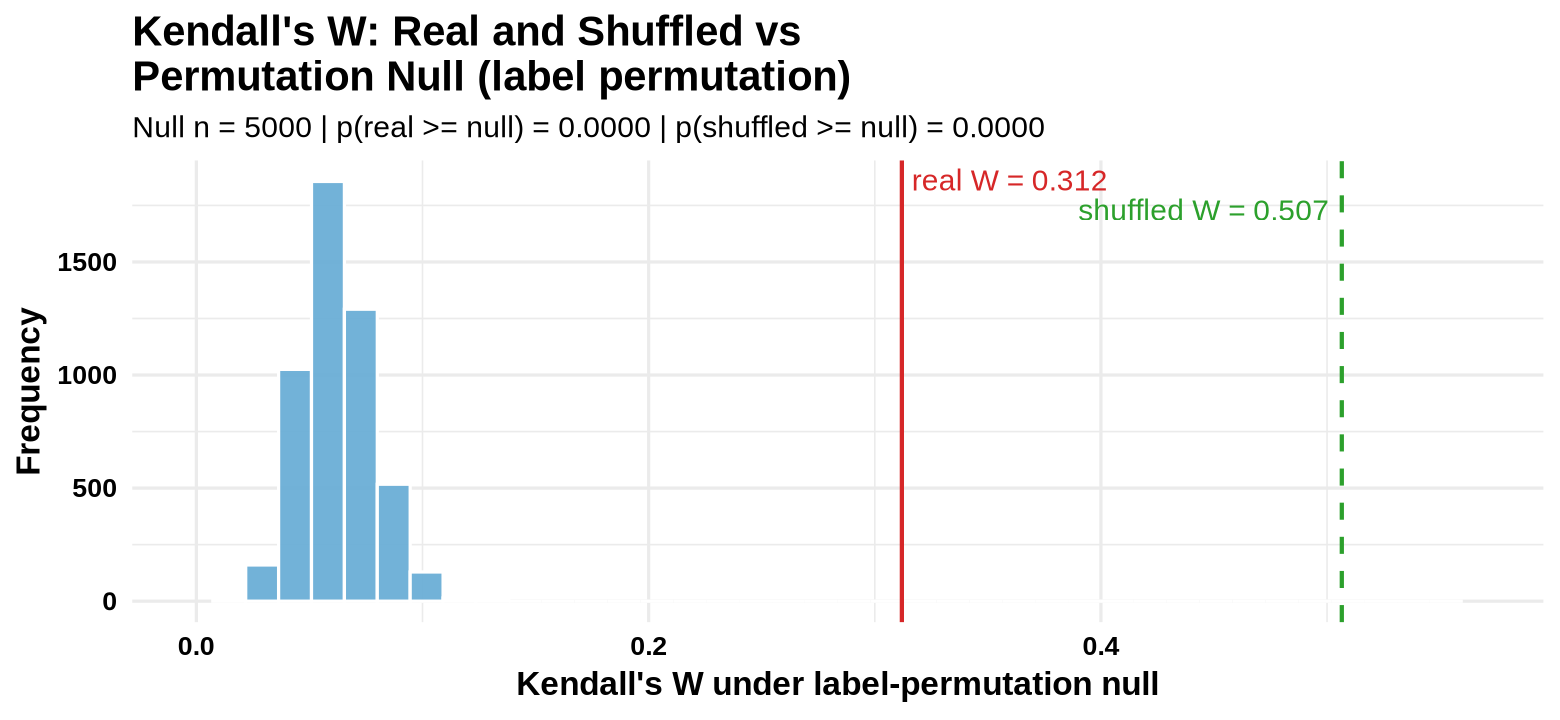

In [79]:
# Plot the permutation-null distribution with real and shuffled W as reference lines
plot_df <- tibble::tibble(W = perm_W)

# Use a compact aspect ratio for this histogram (both display and saved file).
plot_width <- 13
plot_height <- 6
options(repr.plot.width = plot_width, repr.plot.height = plot_height)

x_upper <- max(c(perm_W, real_stats$W, shuf_stats$W), na.rm = TRUE) * 1.12
x_upper <- max(x_upper, 0.12)

empirical_p_shuf <- if (length(perm_W) > 0) mean(perm_W >= shuf_stats$W) else NA_real_

# Keep labels readable even when a reference line is near the right boundary.
shuf_hjust <- ifelse(shuf_stats$W > x_upper * 0.88, 1.05, -0.05)
shuf_vjust <- ifelse(shuf_stats$W > x_upper * 0.88, 3.0, 3.0)

p_perm <- ggplot(plot_df, aes(x = W)) +
  geom_histogram(bins = 40, fill = '#6baed6', color = 'white', alpha = 0.95) +
  geom_vline(xintercept = real_stats$W, color = '#d62728', linewidth = 1.2) +
  geom_vline(xintercept = shuf_stats$W, color = '#2ca02c', linewidth = 1.2, linetype = 'dashed') +
  annotate(
    'text', x = real_stats$W, y = Inf,
    label = sprintf('real W = %.3f', real_stats$W),
    vjust = 1.5, hjust = -0.05, color = '#d62728', size = 6.3
  ) +
  annotate(
    'text', x = shuf_stats$W, y = Inf,
    label = sprintf('shuffled W = %.3f', shuf_stats$W),
    vjust = shuf_vjust, hjust = shuf_hjust, color = '#2ca02c', size = 6.3
  ) +
  scale_x_continuous(limits = c(0, x_upper)) +
  labs(
    title = "Kendall's W: Real and Shuffled vs \nPermutation Null (label permutation)",
    subtitle = sprintf(
      'Null n = %d | p(real >= null) = %s | p(shuffled >= null) = %s',
      n_permutations,
      ifelse(is.na(empirical_p_real), 'NA', sprintf('%.4f', empirical_p_real)),
      ifelse(is.na(empirical_p_shuf), 'NA', sprintf('%.4f', empirical_p_shuf))
    ),
    x = "Kendall's W under label-permutation null",
    y = 'Frequency'
  ) +
  theme_minimal(base_size = 20) +
  theme(
    plot.title = element_text(face = 'bold', size = 25),
    plot.subtitle = element_text(size = 18),
    axis.text.x = element_text(face = 'bold', colour = 'black'),
    axis.text.y = element_text(face = 'bold', colour = 'black'),
    axis.title.x = element_text(face = 'bold'),
    axis.title.y = element_text(face = 'bold')
  )

perm_plot_out <- file.path(gene_rel_dir, 'kendall_w_permutation_null_histogram.png')
ggsave(perm_plot_out, p_perm, width = plot_width, height = plot_height, dpi = 300, bg = 'white')
cat(sprintf('Saved -> %s\n', perm_plot_out))


# Summarize phenotype specificity as mean off-diagonal Spearman correlation per profile
# for both original and shuffled feature spaces.
compute_profile_specificity <- function(corr_matrix, feature_space_label) {
  tibble::tibble(profile = colnames(corr_matrix)) %>%
    mutate(
      mean_rho = sapply(profile, function(p) {
        v <- corr_matrix[p, setdiff(colnames(corr_matrix), p)]
        mean(v, na.rm = TRUE)
      }),
      feature_space = feature_space_label
    )
}

profile_specificity_real <- compute_profile_specificity(orig_consistency$corr_matrix, 'original')
profile_specificity_shuf <- compute_profile_specificity(shuf_consistency$corr_matrix, 'shuffled')

profile_specificity <- bind_rows(profile_specificity_real, profile_specificity_shuf) %>%
  arrange(feature_space, mean_rho)

spec_long_out <- file.path(gene_rel_dir, 'profile_specificity_real_vs_shuffled.csv')
readr::write_csv(profile_specificity, spec_long_out)
cat(sprintf('Saved -> %s\n', spec_long_out))

profile_specificity_wide <- profile_specificity %>%
  select(profile, feature_space, mean_rho) %>%
  tidyr::pivot_wider(names_from = feature_space, values_from = mean_rho)

if (all(c('original', 'shuffled') %in% colnames(profile_specificity_wide))) {
  profile_specificity_wide <- profile_specificity_wide %>%
    mutate(delta_real_minus_shuffled = original - shuffled) %>%
    arrange(delta_real_minus_shuffled)
}

spec_wide_out <- file.path(gene_rel_dir, 'profile_specificity_real_vs_shuffled_wide.csv')
readr::write_csv(profile_specificity_wide, spec_wide_out)
cat(sprintf('Saved -> %s\n', spec_wide_out))


p_perm

The histogram shows the distribution of Kendall's W across 5000 label permutations (null), with both observed statistics overlaid: real W (solid red line, 0.312) and shuffled-feature-space W (dashed green line, 0.507). The null distribution is tightly centered below 0.1, and both observed values lie far to the right of the null support (empirical p(real >= null) = 0.0000; empirical p(shuffled >= null) = 0.0000).

Comparing the two observed lines, the shuffled feature space yields a substantially larger concordance than the original feature space in this run. This indicates that the rank-agreement structure is not explained by random label assignment alone and supports the importance of interpreting phenotype-level concordance jointly with the real-vs-shuffled comparison.
